### Постановка задачи

**Бизнес-постановка задачи:**
Наша задача - разработать модель, которая позволит классифицировать новых клиентов по уровню медицинского риска. Это может быть полезно для страховых компаний при определении страховых взносов и предложении персонализированных страховых продуктов.

**Постановка ML-задачи:**
Это задача **классификации**, где мы будем предсказывать категориальную переменную (уровень риска: низкий, средний, высокий) на основе имеющихся признаков клиента (возраст, пол, ИМТ, количество детей, курение, регион проживания, а также, возможно, их предсказанные медицинские расходы).

### Набор данных

Мы будем использовать набор данных "Medical Insurance Cost Prediction", который содержит информацию о различных характеристиках пациентов и их соответствующих медицинских расходах. Для задачи классификации по уровню риска нам потребуется определить эти уровни на основе медицинских расходов.

### Выбор метрики качества

Для задачи классификации, где мы предсказываем категориальное значение (уровень риска), подходящими метриками являются:

*   **Accuracy (Точность):** Доля правильно классифицированных объектов от общего числа объектов.
*   **Precision (Точность):** Доля правильно классифицированных положительных объектов среди всех объектов, которые модель классифицировала как положительные.
*   **Recall (Полнота):** Доля правильно классифицированных положительных объектов среди всех реальных положительных объектов.
*   **F1-score:** Гармоническое среднее Precision и Recall. Полезен, когда есть дисбаланс классов.
*   **ROC-AUC:** Площадь под кривой операционных характеристик приемника. Измеряет способность модели различать классы.

Для данной задачи, где важна правильная идентификация клиентов с высоким риском, **Precision** и **Recall** (или **F1-score**) для класса "высокого риска" будут очень важны. Также **Accuracy** и **ROC-AUC** дадут общее представление о качестве модели.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Misc
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/medical-insurance-cost-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medical-insurance-cost-prediction' dataset.
Path to dataset files: /kaggle/input/medical-insurance-cost-prediction


### Разведочный анализ данных (EDA)

Проведем предварительный анализ набора данных, чтобы понять его структуру, характеристики признаков и выявить возможные проблемы или интересные закономерности.

In [11]:
# Базовые характеристики и статистика набора данных
print("Размер набора данных (строки, столбцы):", df.shape)
print("\nИнформация о наборе данных:")
df.info()
print("\nОписание набора данных (статистика):")
display(df.describe(include='all'))

# Проверка на наличие пропущенных значений
print("\nКоличество пропущенных значений по столбцам:")
print(df.isnull().sum())

Размер набора данных (строки, столбцы): (100000, 54)

Информация о наборе данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000



Количество пропущенных значений по столбцам:
person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                        

### Выводы по данным

На основе проведенного анализа можно сделать следующие выводы:

*   **Структура данных:** Набор данных содержит информацию о 100,000 клиентах (строки) и 54 признаках (столбцы), включая демографические данные, информацию о состоянии здоровья, страховом плане и медицинских расходах.
*   **Пропущенные значения:** Признак `alcohol_freq` имеет значительное количество пропущенных значений (30083 из 100000). Остальные признаки не содержат пропущенных значений. Необходимо будет решить, как обрабатывать пропущенные значения в столбце `alcohol_freq` (например, заполнить медианой, модой или удалить строки/столбец).
*   **Типы данных:** Признаки имеют соответствующие типы данных (числовые и категориальные). Признаки типа `object` являются категориальными и потребуют кодирования для использования в большинстве моделей машинного обучения.
*   **Распределение категориальных признаков:**
    *   Признаки `sex`, `region`, `urban_rural`, `education`, `marital_status`, `employment_status`, `smoker`, `plan_type`, `network_tier`, `alcohol_freq` являются категориальными.
    *   Распределения по категориям в целом сбалансированы для таких признаков, как `sex`, `region`, `urban_rural`, `education`, `marital_status`, `employment_status`.
    *   Признак `smoker` имеет сильный дисбаланс классов (значительно больше некурящих), что подтверждает его потенциальную важность как предиктора.
*   **Взаимосвязь признаков:**
    *   Признаки, связанные с состоянием здоровья (`bmi`, `risk_score`, `chronic_count`, `hypertension`, `diabetes`, `asthma`, `copd`, `cardiovascular_disease`, `cancer_history`, `kidney_disease`, `liver_disease`, `arthritis`, `mental_health`, `is_high_risk`, `had_major_procedure`) и использованием медицинских услуг (`visits_last_year`, `hospitalizations_last_3yrs`, `days_hospitalized_last_3yrs`, `medication_count`, `claims_count`, `avg_claim_amount`, `total_claims_paid`, `proc_imaging_count`, `proc_surgery_count`, `proc_physio_count`, `proc_consult_count`, `proc_lab_count`) вероятно, будут сильно коррелировать с медицинскими расходами и, соответственно, с уровнем риска.
    *   Признак `smoker` также, как ожидается, будет иметь сильную положительную корреляцию с медицинскими расходами.
    *   Демографические признаки (`age`, `sex`, `region`, `urban_rural`, `income`, `education`, `marital_status`, `employment_status`, `household_size`, `dependents`) также могут оказывать влияние на расходы, но их взаимосвязь может быть менее выраженной или нелинейной.

**Дальнейшие шаги:**

1.  **Обработка пропущенных значений:** Определить стратегию для обработки пропущенных значений в столбце `alcohol_freq`.
2.  **Кодирование категориальных признаков:** Применить подходящие методы кодирования (например, One-Hot Encoding) к категориальным признакам.
3.  **Преобразование целевой переменной:** Рассмотреть преобразование (например, логарифмирование) целевой переменной `annual_medical_cost` для уменьшения скошенности, если это требуется для выбранной модели классификации (например, если классификация будет основана на пороговых значениях расходов).
4.  **Выделение целевой переменной (уровня риска):** Определить, как будут формироваться классы риска (низкий, средний, высокий) на основе медицинских расходов (`annual_medical_cost`) или других признаков, если `is_high_risk` является бинарной целевой переменной.
5.  **Масштабирование числовых признаков:** Применить масштабирование (например, StandardScaler) к числовым признакам, особенно если используются модели, чувствительные к масштабу данных.
6.  **Выбор и обучение модели классификации:** Выбрать подходящую модель классификации и обучить ее на подготовленных данных.
7.  **Оценка модели:** Оценить производительность модели с использованием выбранных метрик качества (Accuracy, Precision, Recall, F1-score, ROC-AUC).

### Визуализация распределения признаков

Построим графики для визуализации распределения числовых и категориальных признаков.

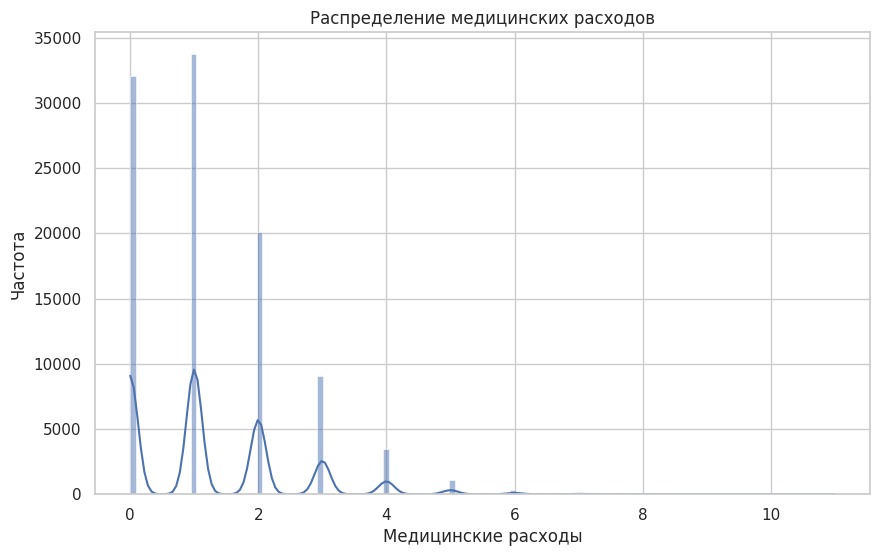

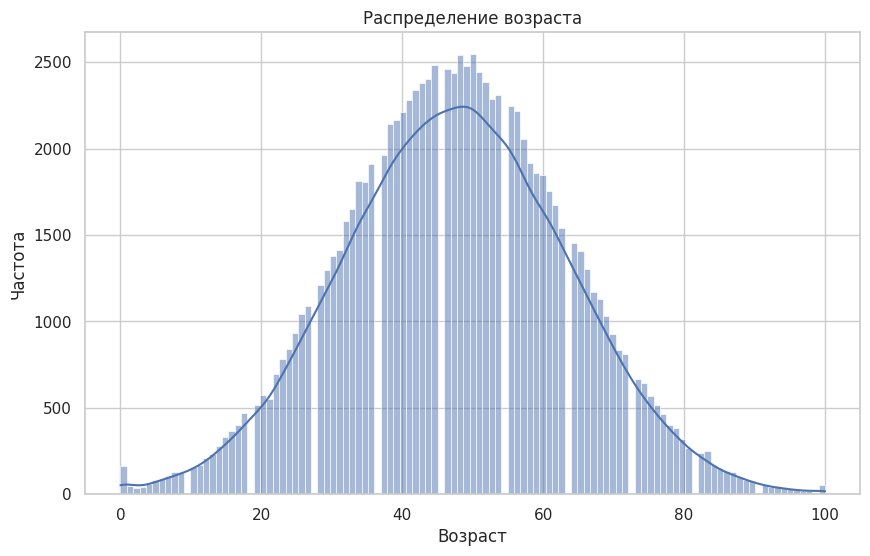

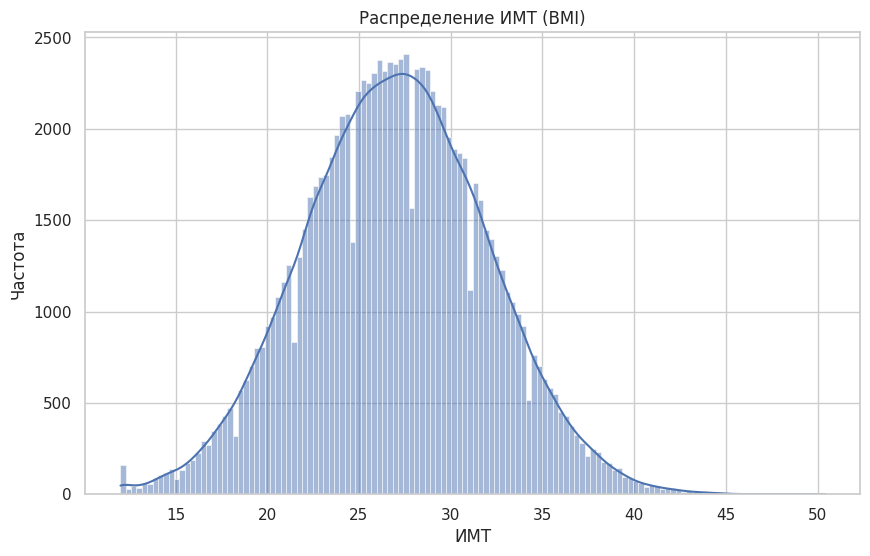

In [14]:
# Визуализация распределения числовых признаков

# Распределение медицинских расходов
plt.figure(figsize=(10, 6))
sns.histplot(df['medication_count'], kde=True)
plt.title('Распределение медицинских расходов')
plt.xlabel('Медицинские расходы')
plt.ylabel('Частота')
plt.show()


# Распределение возраста
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()



# Распределение ИМТ (BMI)
plt.figure(figsize=(10, 6))
sns.histplot(df['bmi'], kde=True)
plt.title('Распределение ИМТ (BMI)')
plt.xlabel('ИМТ')
plt.ylabel('Частота')
plt.show()



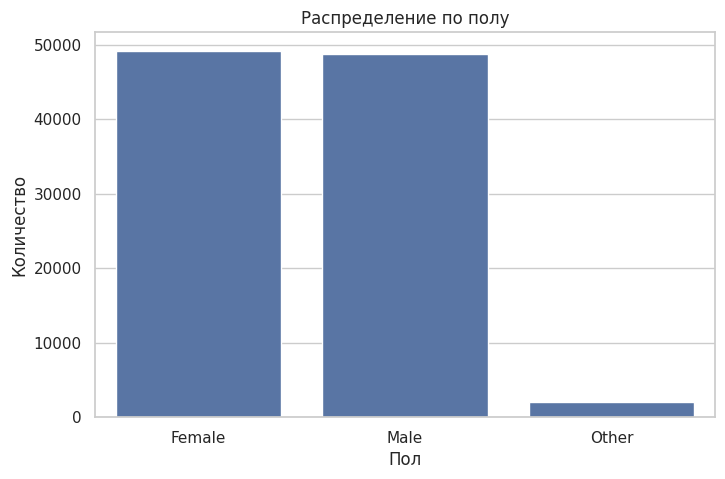

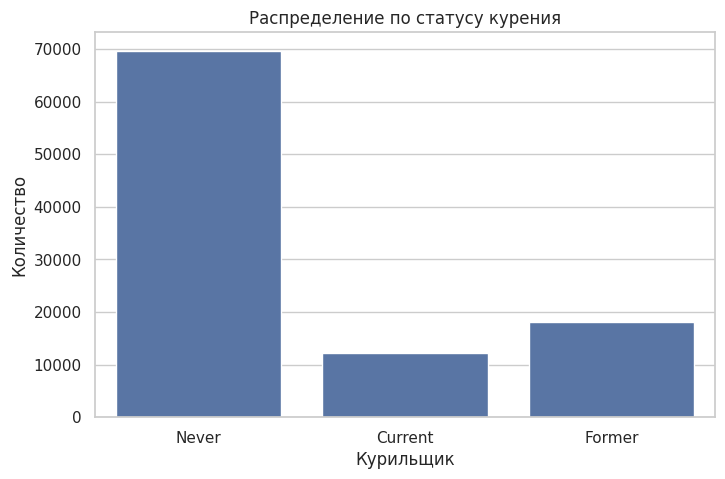

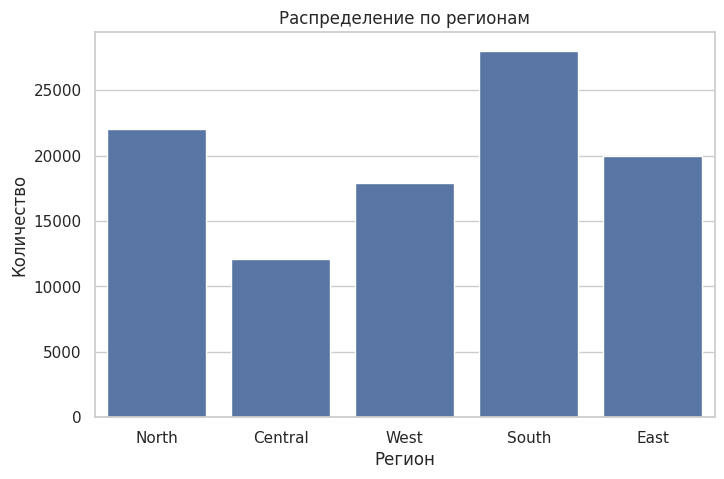

In [15]:
# Визуализация распределения категориальных признаков

# Распределение по полу
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', data=df)
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()



# Распределение по статусу курения
plt.figure(figsize=(8, 5))
sns.countplot(x='smoker', data=df)
plt.title('Распределение по статусу курения')
plt.xlabel('Курильщик')
plt.ylabel('Количество')
plt.show()



# Распределение по регионам
plt.figure(figsize=(8, 5))
sns.countplot(x='region', data=df)
plt.title('Распределение по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество')
plt.show()


### Анализ взаимосвязи признаков и целевой переменной

Рассмотрим, как различные признаки связаны с медицинскими расходами.

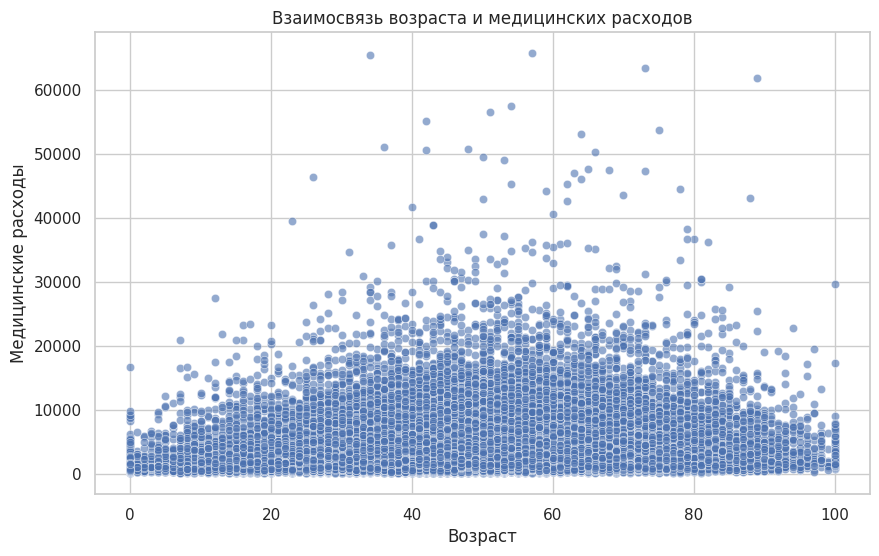

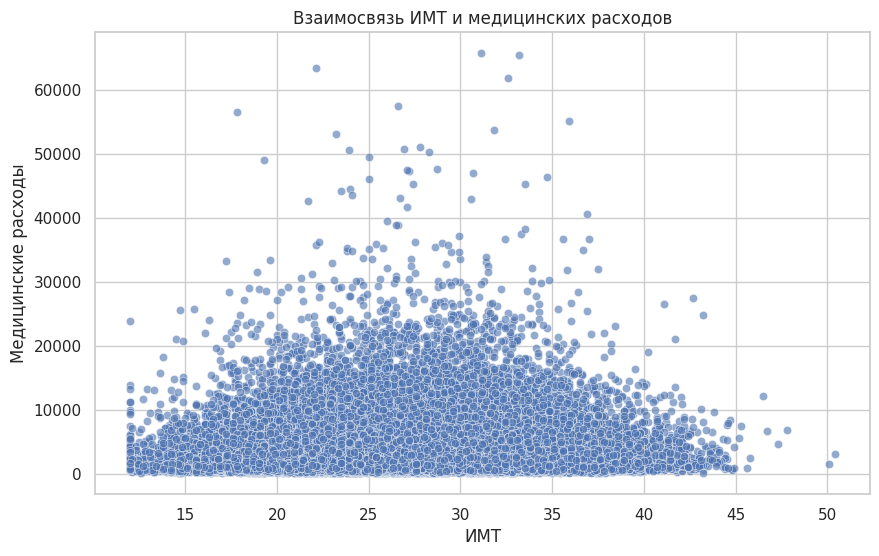

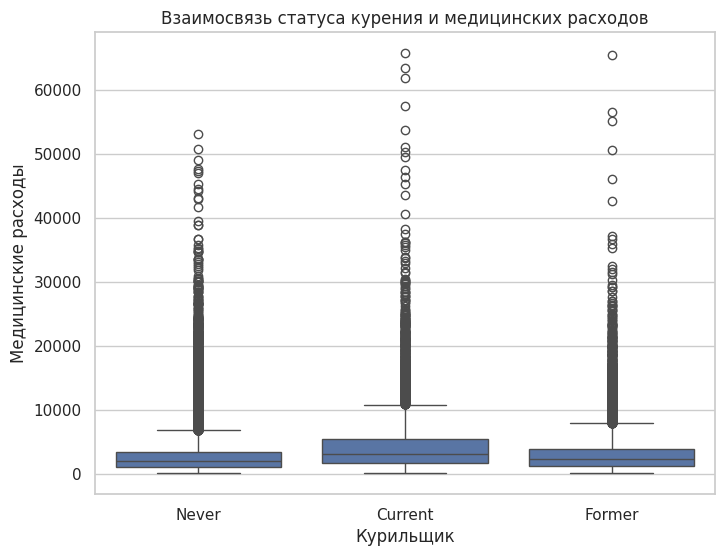

In [18]:
# Взаимосвязь возраста и расходов
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='annual_medical_cost', data=df, alpha=0.6)
plt.title('Взаимосвязь возраста и медицинских расходов')
plt.xlabel('Возраст')
plt.ylabel('Медицинские расходы')
plt.show()



# Взаимосвязь ИМТ и расходов
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='annual_medical_cost', data=df, alpha=0.6)
plt.title('Взаимосвязь ИМТ и медицинских расходов')
plt.xlabel('ИМТ')
plt.ylabel('Медицинские расходы')
plt.show()



# Взаимосвязь статуса курения и расходов
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='annual_medical_cost', data=df)
plt.title('Взаимосвязь статуса курения и медицинских расходов')
plt.xlabel('Курильщик')
plt.ylabel('Медицинские расходы')
plt.show()


### Корреляционный анализ числовых признаков

Построим матрицу корреляций для числовых признаков, чтобы количественно оценить их линейные взаимосвязи.

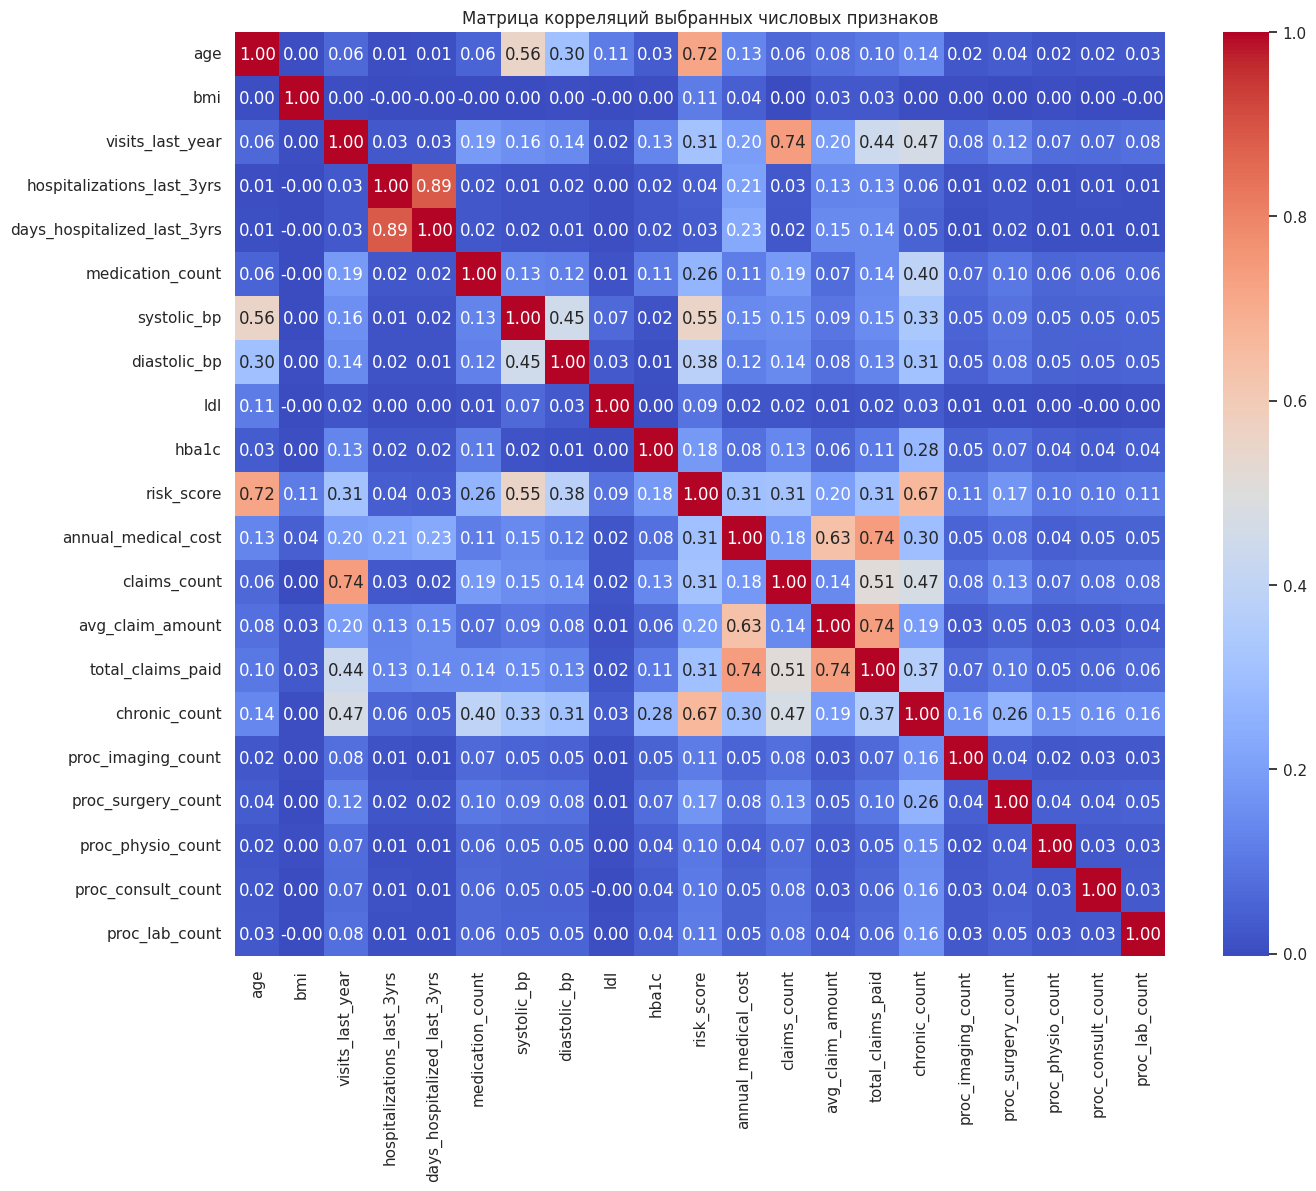

In [20]:
# Корреляционная матрица для числовых признаков
# Выбираем признаки, которые, вероятно, сильно коррелируют с медицинскими расходами и риском.
numerical_cols_for_corr = [
    'age',
    'bmi',
    'visits_last_year',
    'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs',
    'medication_count',
    'systolic_bp',
    'diastolic_bp',
    'ldl',
    'hba1c',
    'risk_score',
    'annual_medical_cost',
    'claims_count',
    'avg_claim_amount',
    'total_claims_paid',
    'chronic_count',
    'proc_imaging_count',
    'proc_surgery_count',
    'proc_physio_count',
    'proc_consult_count',
    'proc_lab_count'
]

correlation_matrix = df[numerical_cols_for_corr].corr()

plt.figure(figsize=(15, 12)) # Увеличим размер для лучшей читаемости
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций выбранных числовых признаков')
plt.show()



### Вывод по корреляционному анализу

На основе построенной матрицы корреляций для выбранных числовых признаков можно отметить следующее:

*   **Сильная положительная корреляция с `annual_medical_cost`:** Признаки `total_claims_paid`, `avg_claim_amount`, `claims_count`, `days_hospitalized_last_3yrs`, `hospitalizations_last_3yrs`, `visits_last_year`, `risk_score`, `medication_count`, `systolic_bp`, `diastolic_bp`, `hba1c` имеют заметную положительную корреляцию с `annual_medical_cost`. Это логично, поскольку эти признаки напрямую связаны с состоянием здоровья, использованием медицинских услуг и оценкой риска, что, как правило, ведет к более высоким медицинским расходам.
*   **Умеренная положительная корреляция с `annual_medical_cost`:** Признаки `age`, `bmi`, `chronic_count`, `proc_imaging_count`, `proc_surgery_count`, `proc_physio_count`, `proc_consult_count`, `proc_lab_count` также показывают положительную корреляцию с `annual_medical_cost`, но она менее выражена по сравнению с предыдущей группой признаков. Возраст и ИМТ являются известными факторами риска, а количество хронических заболеваний и медицинских процедур напрямую влияют на расходы.
*   **Слабая или отсутствует корреляция с `annual_medical_cost`:** Признак `ldl` имеет очень слабую корреляцию с медицинскими расходами.
*   **Мультиколлинеарность:** Наблюдаются высокие корреляции между некоторыми признаками, не являющимися целевой переменной. Например, `hospitalizations_last_3yrs` и `days_hospitalized_last_3yrs` сильно коррелируют (0.89), что ожидаемо. `visits_last_year` также сильно коррелирует с `claims_count` (0.74) и умеренно с `chronic_count` (0.47). `risk_score` имеет высокую корреляцию с `age` (0.72) и `systolic_bp` (0.56), что также является ожидаемым, поскольку эти факторы используются для расчета оценки риска. Признаки, связанные с медицинскими процедурами (`proc_imaging_count`, `proc_surgery_count`, и т.д.), умеренно коррелируют с `chronic_count`. Высокая мультиколлинеарность между признаками может повлиять на некоторые модели (например, линейные), делая их менее интерпретируемыми или менее стабильными. Для таких моделей, возможно, потребуется выбор признаков или использование методов регуляризации.

**Общие выводы:**

Корреляционный анализ подтверждает, что многие признаки в наборе данных имеют логичные взаимосвязи с медицинскими расходами. Признаки, связанные с состоянием здоровья, использованием медицинских услуг и оценкой риска, являются наиболее сильными предикторами. Наличие мультиколлинеарности между некоторыми признаками следует учитывать при выборе и построении модели.

### Общий вывод по проведенному анализу данных и дальнейшие шаги

На основе разведочного анализа данных мы получили хорошее представление о структуре и характеристиках набора данных.

**Основные выводы:**

*   Набор данных обширен (100,000 записей, 54 признака) и содержит разнообразную информацию о клиентах, их здоровье, страховых планах и медицинских расходах.
*   Присутствуют пропущенные значения только в столбце `alcohol_freq`, которые потребуют обработки.
*   Многие признаки, особенно связанные со здоровьем, использованием медицинских услуг и оценкой риска (`risk_score`, `total_claims_paid`, `hospitalizations_last_3yrs`, `smoker` и др.), сильно коррелируют с медицинскими расходами, которые являются ключевым фактором для определения уровня риска.
*   Распределение медицинских расходов сильно скошено, что важно учитывать при определении пороговых значений для классов риска или при использовании моделей, чувствительных к распределению целевой переменной.
*   Некоторые признаки имеют высокую мультиколлинеарность (например, `hospitalizations_last_3yrs` и `days_hospitalized_last_3yrs`), что может потребовать внимания при выборе модели.
*   Категориальные признаки (`sex`, `region`, `urban_rural`, `education`, `marital_status`, `employment_status`, `smoker`, `plan_type`, `network_tier`, `alcohol_freq`) необходимо будет преобразовать для использования в большинстве моделей машинного обучения.

**Дальнейшие шаги:**

1.  **Определение классов риска:** Четко определить пороговые значения для разделения клиентов на категории низкого, среднего и высокого медицинского риска на основе `annual_medical_cost` или других релевантных признаков, если целевая переменная `is_high_risk` является бинарной.
2.  **Предобработка данных:**
    *   Обработка пропущенных значений в столбце `alcohol_freq`.
    *   Кодирование категориальных признаков (например, с использованием One-Hot Encoding).
    *   Масштабирование числовых признаков, если это необходимо для выбранной модели.
3.  **Разделение данных:** Разделить набор данных на обучающую, валидационную и тестовую выборки.
4.  **Выбор и обучение модели:** Выбрать одну или несколько подходящих моделей классификации (например, логистическая регрессия, случайный лес, градиентный бустинг) и обучить их на обучающей выборке.
5.  **Оценка модели:** Оценить производительность обученных моделей на валидационной выборке с использованием выбранных метрик качества (Accuracy, Precision, Recall, F1-score, ROC-AUC), уделяя особое внимание метрикам для класса высокого риска.
6.  **Оптимизация гиперпараметров:** При необходимости провести настройку гиперпараметров моделей для улучшения их производительности.
7.  **Финальная оценка:** Оценить лучшую модель на отложенной тестовой выборке.
8.  **Интерпретация модели (опционально):** Понять, какие признаки оказывают наибольшее влияние на предсказание уровня риска.